# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Alden Nabil Wibowo Effendy
- **Email:** ayyopizzashere@gmail.com
- **ID Dicoding:** CDCC001D6Y0747

## Menentukan Pertanyaan Bisnis

- Kategori produk apa yang paling banyak terjual dan kategori mana yang menghasilkan pendapatan (revenue) tertinggi bagi perusahaan?

- Bagaimana distribusi geografis pelanggan berdasarkan negara bagian (state) dan wilayah mana yang memiliki potensi pasar terbesar?

- Bagaimana profil segmentasi pelanggan berdasarkan analisis RFM (Recency, Frequency, Monetary)?

## Import Semua Packages/Library yang Digunakan

In [2]:
pip install matplotlib seaborn pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from matplotlib.ticker import FuncFormatter

# Konfigurasi visualisasi
sns.set(style='darkgrid')

## Data Wrangling

### Gathering Data

In [4]:
# Load dataset
customers_df = pd.read_csv('data/customers_dataset.csv')
orders_df = pd.read_csv('data/orders_dataset.csv')
order_items_df = pd.read_csv('data/order_items_dataset.csv')
products_df = pd.read_csv('data/products_dataset.csv')
category_translation_df = pd.read_csv('data/product_category_name_translation.csv')
order_payments_df = pd.read_csv('data/order_payments_dataset.csv')

# Menampilkan 5 baris pertama dari data pesanan
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**
- Dataset memiliki sangat banyak variabel. Jika kita fokus ke orders_dataset, kita memiliki informasi mengenai order dari perusahaan Olist. Data terdiri dari variabel berikut:
1. order_id
2. customer_id
3. order_status
4. order_purchase_timestamp
5. order_approved_at
6. order_delivered_carrier_date
7. order_delivered_customer_date
8. order_estimated_delivery_date

### Assessing Data

In [5]:
# Memeriksa info dasar data
print(orders_df.info())
print(customers_df.duplicated().sum())
print(order_items_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None
0
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


**Insight:**
- Terdapat kolom tanggal (berakhiran date) ada orders_df yang masih bertipe object, perlu dikonversi ke datetime.
- Data tidak memiliki duplikat dan tidak memiliki missing value pada semua variabel

### Cleaning Data

In [6]:
# 1. Mengubah tipe data kolom tanggal
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# 2. Menggabungkan nama kategori bahasa Inggris ke data produk
# Menggunakan left join agar produk yang tidak punya kategori tetap terjaga
products_df = products_df.merge(category_translation_df, on='product_category_name', how='left')

# Mengisi nilai kosong (NaN) pada kategori bahasa Inggris dengan 'others'
products_df['product_category_name_english'].fillna('others', inplace=True)

# 3. Menggabungkan dataset utama (Orders, Items, Products, Customers)
main_df = orders_df.merge(order_items_df, on='order_id', how='left')
main_df = main_df.merge(products_df, on='product_id', how='left')
main_df = main_df.merge(customers_df, on='customer_id', how='left')

# Menghapus data yang tidak memiliki order_id atau product_id (data tidak valid)
rows_before = main_df.shape[0]
main_df.dropna(subset=['order_id', 'product_id'], inplace=True)
rows_after = main_df.shape[0]

print(f"Jumlah baris sebelum cleaning: {rows_before}")
print(f"Jumlah baris setelah cleaning: {rows_after}")
print(f"Total baris yang dihapus (missing ID): {rows_before - rows_after}")

# Menampilkan 5 data teratas
main_df.head()

C:\Users\alden\AppData\Local\Temp\ipykernel_29128\3605297780.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df['product_category_name_english'].fillna('others', inplace=True)


Jumlah baris sebelum cleaning: 113425
Jumlah baris setelah cleaning: 112650
Total baris yang dihapus (missing ID): 775


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,4.0,500.0,19.0,8.0,13.0,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,1.0,400.0,19.0,13.0,19.0,perfumery,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,1.0,420.0,24.0,19.0,21.0,auto,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,3.0,450.0,30.0,10.0,20.0,pet_shop,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,4.0,250.0,51.0,15.0,15.0,stationery,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


**Insight:**
- 5 Kolom data berisi tanggal telah diperbaiki tipenya agar bisa diolah untuk analisis waktu. menggunakan format datetime64

- Nama kategori produk telah digabungkan dengan versi Bahasa Inggris. Kategori yang tidak memiliki terjemahan telah diisi dengan nilai 'others'.

- Jumlah baris sebelum penghapusan: 113.425

- Jumlah baris setelah penghapusan: 112.650

- Total baris yang dihapus: 775 (Ini adalah pesanan yang tidak memiliki informasi produk atau ID pesanan yang valid setelah proses merge).

## Exploratory Data Analysis (EDA)

### Explorasi top category sold

In [7]:
# Grouping berdasarkan kategori produk
category_summary = main_df.groupby('product_category_name_english').agg({
    'order_item_id': 'count',
    'price': 'sum'
}).rename(columns={'order_item_id': 'order_count', 'price': 'total_revenue'}).sort_values(by='order_count', ascending=False)

category_summary.head(10)

,order_count,total_revenue
product_category_name_english,,
bed_bath_table,11115,1036988.68
health_beauty,9670,1258681.34
sports_leisure,8641,988048.97
furniture_decor,8334,729762.49
computers_accessories,7827,911954.32
housewares,6964,632248.66
watches_gifts,5991,1205005.68
telephony,4545,323667.53
garden_tools,4347,485256.46


In [8]:
# Menghitung jumlah pelanggan unik per negara bagian
state_dist = main_df.groupby('customer_state').customer_id.nunique().sort_values(ascending=False).reset_index()

**Insight:**
- Berdasarkan kategori, dapat dilihat bahwa kategori barang yang paling sering dibeli pelanggan adalah bet_bath_tablem health_beauty, dan sports_leisure. Namun kategori dengan total revenue tertinggi bukanlah yang paling banyak dijual, melainkan health_beauty dan watches_gifts.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

C:\Users\alden\AppData\Local\Temp\ipykernel_29128\4118879310.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="order_count", y="product_category_name_english",
C:\Users\alden\AppData\Local\Temp\ipykernel_29128\4118879310.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_revenue", y="product_category_name_english",


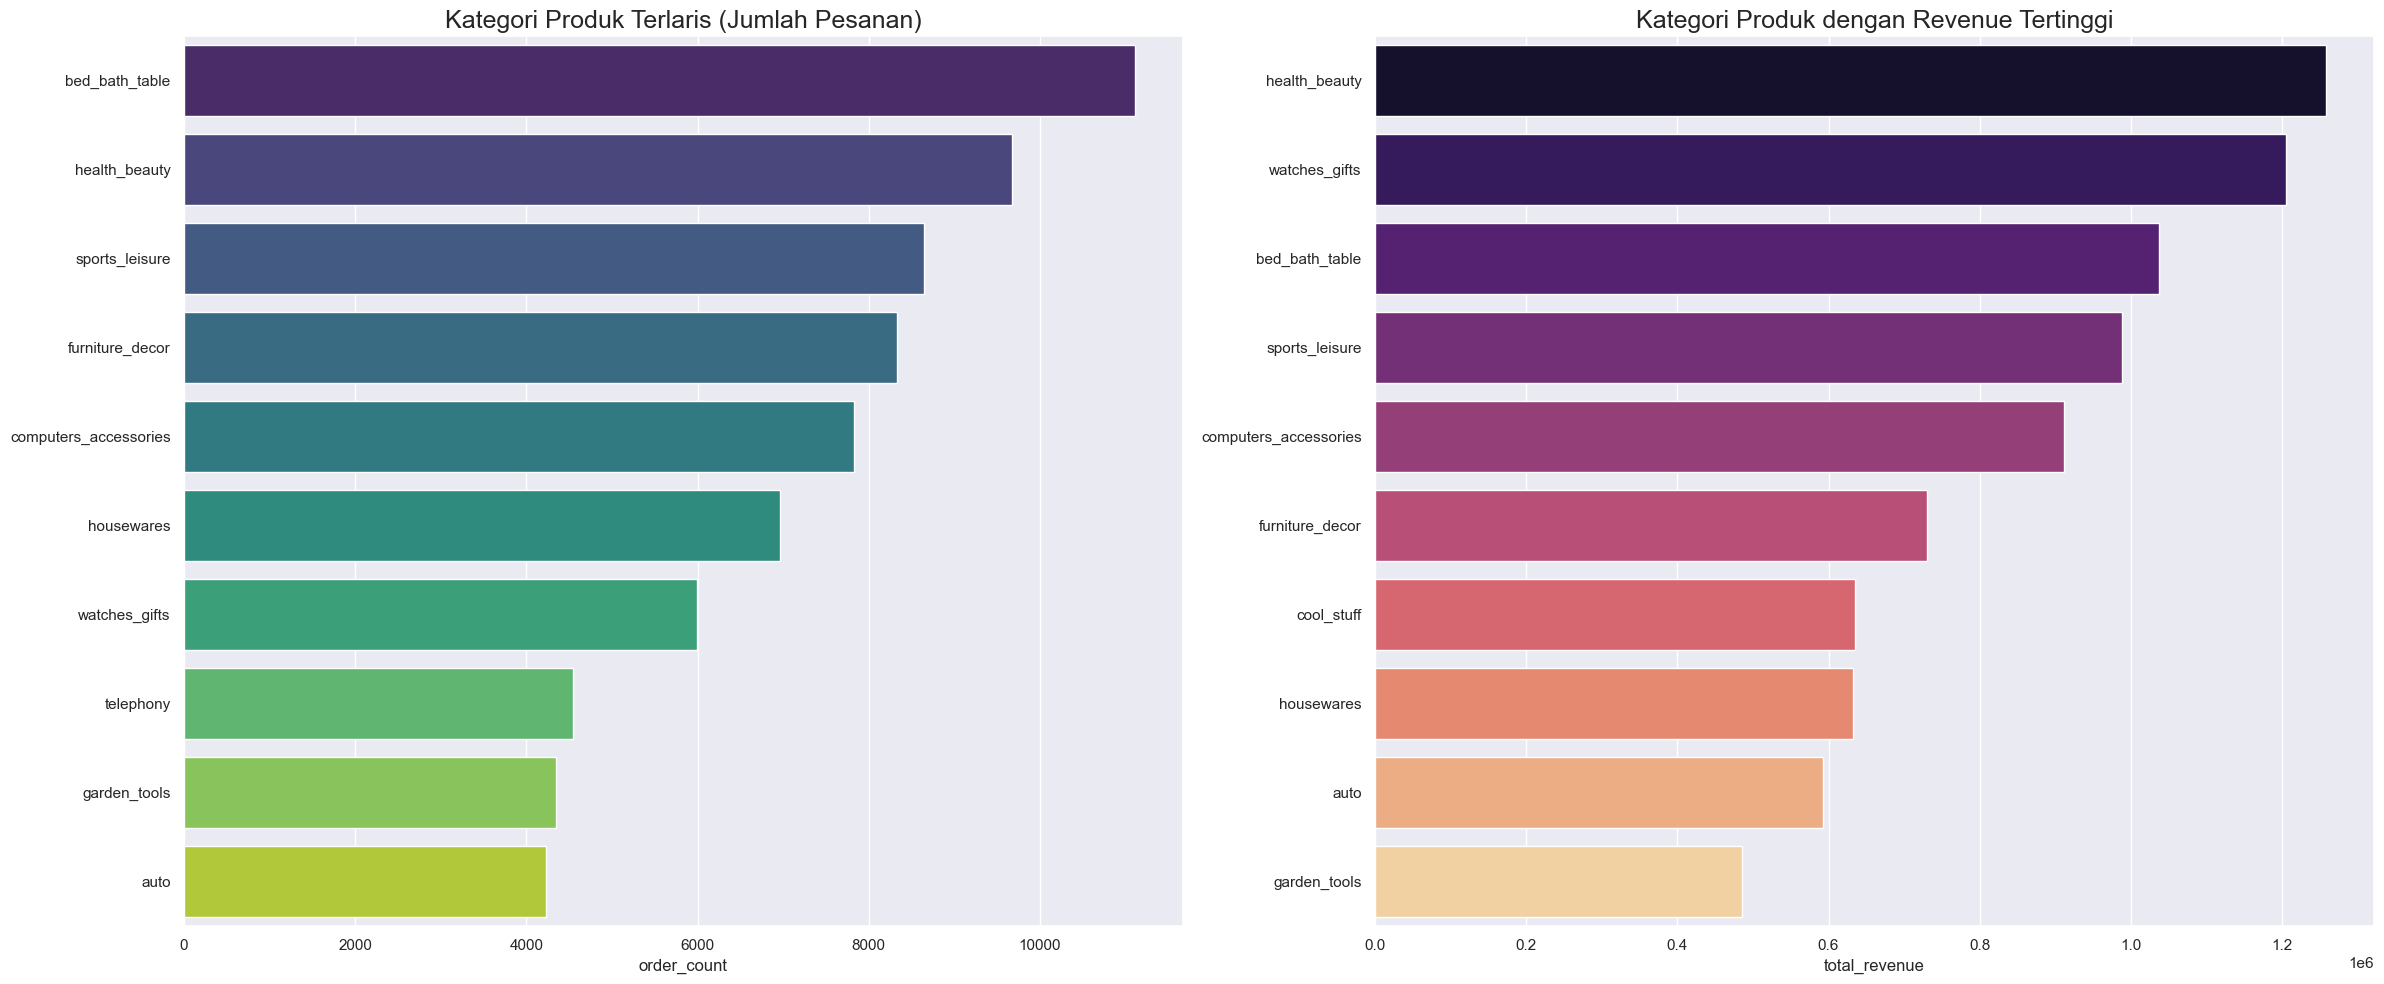

In [22]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 10))

# Visualisasi Order Count
sns.barplot(x="order_count", y="product_category_name_english",
            data=category_summary.head(10).reset_index(), palette="viridis", ax=ax[0])
ax[0].set_title("Kategori Produk Terlaris (Jumlah Pesanan)", loc="center", fontsize=18)
ax[0].set_ylabel(None)

# Visualisasi Total Revenue
sns.barplot(x="total_revenue", y="product_category_name_english",
            data=category_summary.sort_values(by='total_revenue', ascending=False).head(10).reset_index(),
            palette="magma", ax=ax[1])
ax[1].set_title("Kategori Produk dengan Revenue Tertinggi", loc="center", fontsize=18)
ax[1].set_ylabel(None)

plt.tight_layout()
plt.show()

### Pertanyaan 2:

C:\Users\alden\AppData\Local\Temp\ipykernel_29128\2266946131.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="customer_id", y="customer_state", data=state_dist.head(10), palette="coolwarm")


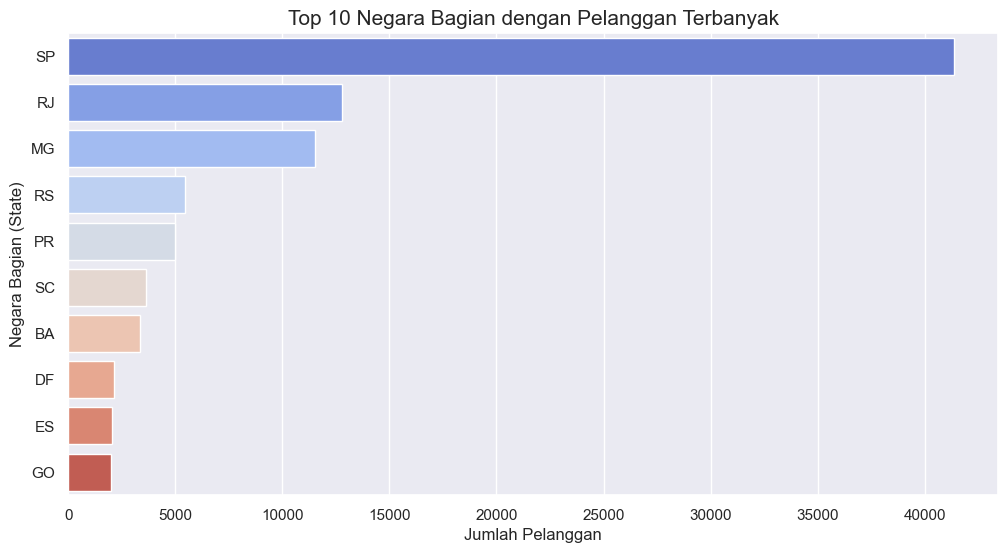

In [16]:
plt.figure(figsize=(12, 6))
sns.barplot(x="customer_id", y="customer_state", data=state_dist.head(10), palette="coolwarm")
plt.title("Top 10 Negara Bagian dengan Pelanggan Terbanyak", fontsize=15)
plt.xlabel("Jumlah Pelanggan")
plt.ylabel("Negara Bagian (State)")
plt.show()

## Analisis Lanjutan (Opsional)

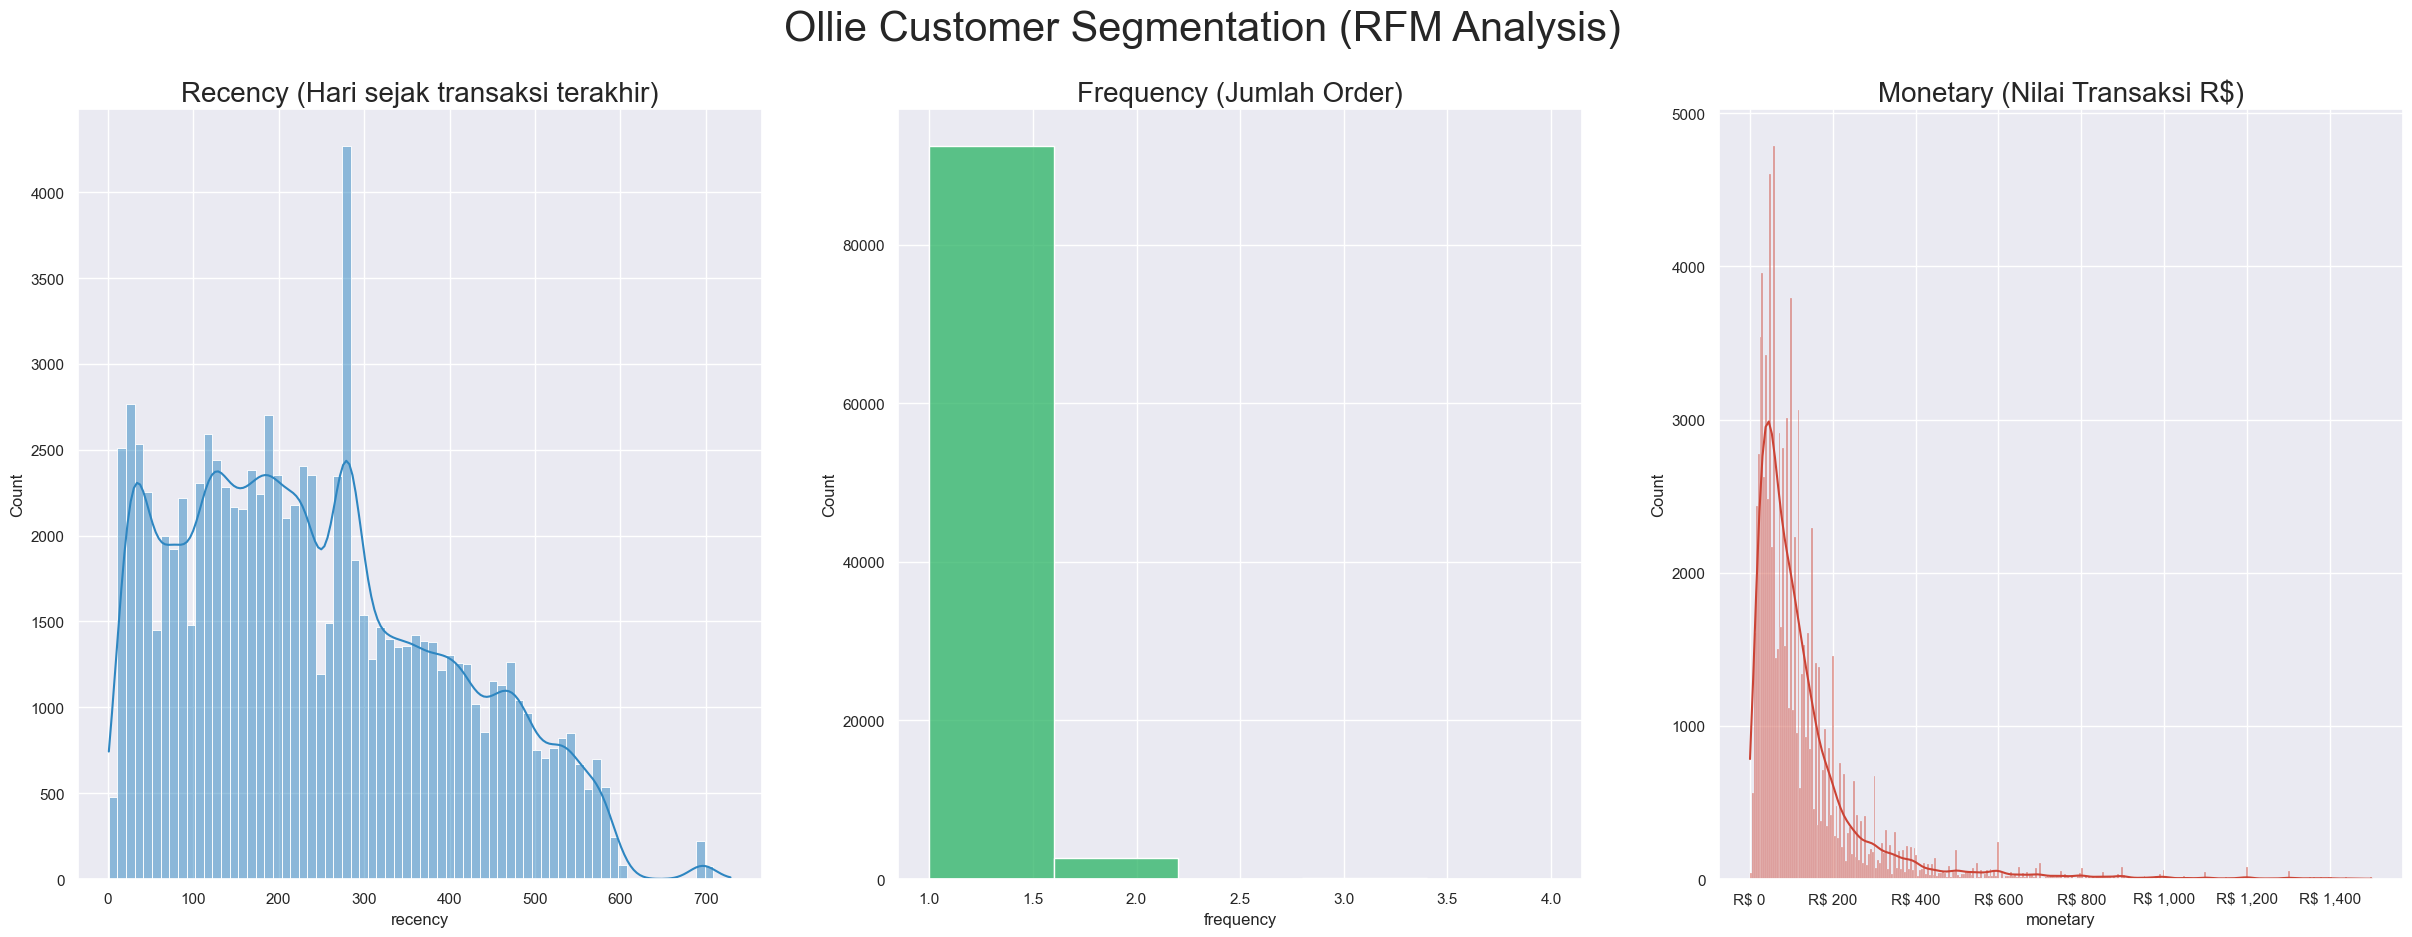

In [18]:
# Menghitung RFM berdasarkan customer_unique_id
snapshot_date = main_df['order_purchase_timestamp'].max() + dt.timedelta(days=1)

# Menghitung metrik RFM
rfm_df = main_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days, # Recency
    'order_id': 'nunique',                                             # Frequency
    'price': 'sum'                                                   # Monetary
}).reset_index()

rfm_df.columns = ['customer_id', 'recency', 'frequency', 'monetary']

# Visualisasi RFM
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))

# Recency
sns.histplot(rfm_df['recency'], kde=True, ax=ax[0], color='#2E86C1')
ax[0].set_title("Recency (Hari sejak transaksi terakhir)", fontsize=20)

# Frequency
sns.histplot(rfm_df[rfm_df['frequency'] < 5]['frequency'], ax=ax[1], color='#28B463', bins=5)
ax[1].set_title("Frequency (Jumlah Order)", fontsize=20)

# Monetary
sns.histplot(rfm_df[rfm_df['monetary'] < 1500]['monetary'], kde=True, ax=ax[2], color='#CB4335')
ax[2].xaxis.set_major_formatter(formatter)
ax[2].set_title("Monetary (Nilai Transaksi R$)", fontsize=20)

plt.suptitle("Ollie Customer Segmentation (RFM Analysis)", fontsize=30)
plt.show()

## Conclusion

- Kesimpulan Pertanyaan 1: Kategori bed_bath_table adalah yang paling banyak dipesan, namun kategori health_beauty memberikan kontribusi pendapatan (revenue) yang signifikan secara keseluruhan.

- Kesimpulan Pertanyaan 2: Sebagian besar pelanggan berasal dari negara bagian SP (São Paulo), menunjukkan pusat aktivitas ekonomi e-commerce terkonsentrasi di wilayah tersebut.

- Kesimpulan Pertanyaan 3: Melalui analisis RFM, kita melihat mayoritas pelanggan hanya melakukan satu kali transaksi (Frequency rendah). Hal ini menandakan perlunya strategi retensi pelanggan yang lebih kuat.